# Notebook 04 — Data Quality Checks

## Purpose
I systematically check for missing values, duplicate rows, impossible values,
and date-range violations across all tables.

## Why this matters
Data quality issues caught here prevent silent errors downstream (e.g. NaN
delivery dates causing incorrect delay calculations).

## Inputs
All 9 raw CSV files from `data/raw/`

## Outputs
`reports/tables/data_quality_report.csv`

## Decisions made here
- Which missing values to impute vs drop
- Whether duplicates are real or data errors
- Whether date inconsistencies require filtering


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.utils import missing_summary, duplicate_summary, save_table
from src.visualization import save_fig

cfg   = load_config()
paths = Paths(cfg)

orders   = pd.read_csv(paths.olist_file('orders', cfg),
                       parse_dates=cfg['preprocessing']['date_columns'])
items    = pd.read_csv(paths.olist_file('order_items', cfg))
payments = pd.read_csv(paths.olist_file('order_payments', cfg))
reviews  = pd.read_csv(paths.olist_file('order_reviews', cfg))
customers= pd.read_csv(paths.olist_file('customers', cfg))
products = pd.read_csv(paths.olist_file('products', cfg))
sellers  = pd.read_csv(paths.olist_file('sellers', cfg))


In [2]:
# Missing value audit across all tables
print("=== Missing Values Summary ===")
all_missing = []
for name, df in [('orders', orders), ('items', items), ('payments', payments),
                 ('reviews', reviews), ('customers', customers),
                 ('products', products), ('sellers', sellers)]:
    ms = missing_summary(df)
    if len(ms) > 0:
        ms.insert(0, 'table', name)
        all_missing.append(ms)
        print(f"\n{name}:")
        print(ms.to_string(index=False))

if all_missing:
    miss_df = pd.concat(all_missing, ignore_index=True)
    save_table(miss_df, 'missing_values_audit',
               reports_dir=str(paths.reports_tabs),
               paper_dir=str(paths.paper_tabs))
else:
    print("No missing values found across any table.")


=== Missing Values Summary ===

orders:
 table                        column  n_missing  pct_missing
orders order_delivered_customer_date       2965         2.98
orders  order_delivered_carrier_date       1783         1.79
orders             order_approved_at        160         0.16

reviews:
  table                 column  n_missing  pct_missing
reviews   review_comment_title      87656        88.34
reviews review_comment_message      58247        58.70

products:
   table                     column  n_missing  pct_missing
products      product_category_name        610         1.85
products        product_name_lenght        610         1.85
products product_description_lenght        610         1.85
products         product_photos_qty        610         1.85
products           product_weight_g          2         0.01
products          product_length_cm          2         0.01
products          product_height_cm          2         0.01
products           product_width_cm          2    

In [3]:
# Duplicate check
print("=== Duplicate Row Check ===")
for name, df, key_col in [
    ('orders',    orders,    'order_id'),
    ('items',     items,     None),
    ('payments',  payments,  None),
    ('reviews',   reviews,   'review_id'),
    ('customers', customers, 'customer_id'),
    ('products',  products,  'product_id'),
]:
    dupe = duplicate_summary(df, subset=[key_col] if key_col else None)
    if dupe['n_duplicates'] > 0:
        print(f"  {name}: {dupe['n_duplicates']} duplicates ({dupe['pct_duplicates']:.2f}%)")
    else:
        print(f"  {name}: No duplicates found")


=== Duplicate Row Check ===
  orders: No duplicates found
  items: No duplicates found
  payments: No duplicates found
  reviews: 814 duplicates (0.82%)
  customers: No duplicates found
  products: No duplicates found


In [4]:
# Date integrity checks on orders
print("=== Date Integrity Checks ===")
# approved_at should be >= purchase timestamp
bad_approved = orders[
    orders['order_approved_at'] < orders['order_purchase_timestamp']
].shape[0]
print(f"Orders approved BEFORE purchase:    {bad_approved}")

# Delivered before approved
bad_delivery = orders[
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_approved_at'].notna()) &
    (orders['order_delivered_customer_date'] < orders['order_approved_at'])
].shape[0]
print(f"Orders delivered BEFORE approved:   {bad_delivery}")

# Extreme delivery delays
delays = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days
extreme_late = (delays > 365).sum()
extreme_early = (delays < -180).sum()
print(f"Orders > 1 year late:              {extreme_late}")
print(f"Orders > 180 days early:           {extreme_early}")


=== Date Integrity Checks ===
Orders approved BEFORE purchase:    0
Orders delivered BEFORE approved:   61
Orders > 1 year late:              0
Orders > 180 days early:           0


In [5]:
# Price / freight outlier check
print("=== Order Item Value Checks ===")
print(f"Price range: {items['price'].min():.2f} – {items['price'].max():.2f} BRL")
print(f"Freight range: {items['freight_value'].min():.2f} – {items['freight_value'].max():.2f} BRL")
print()
zero_price_items = (items['price'] <= 0).sum()
print(f"Items with price <= 0: {zero_price_items}")


=== Order Item Value Checks ===
Price range: 0.85 – 6735.00 BRL
Freight range: 0.00 – 409.68 BRL

Items with price <= 0: 0


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\missing_values_heatmap.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\missing_values_heatmap.png


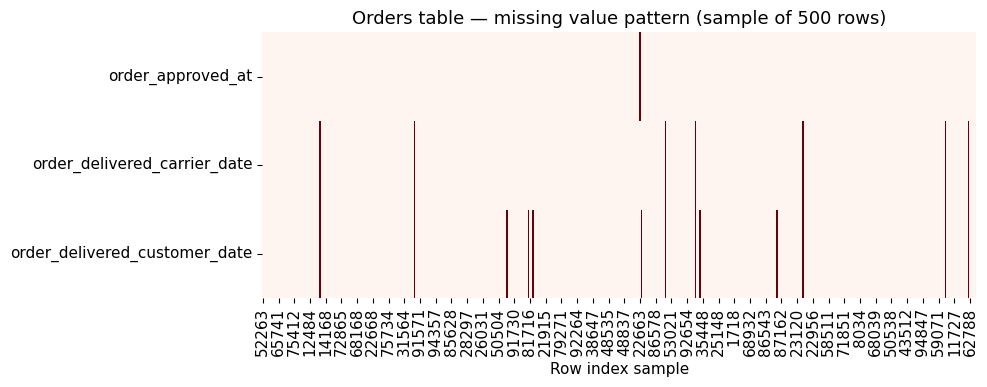

In [6]:
# Missing values heatmap for orders table
fig, ax = plt.subplots(figsize=(10, 4))
null_matrix = orders.isnull()
# Use columns with at least 1 null
null_cols = null_matrix.columns[null_matrix.any()]
if len(null_cols) > 0:
    sns.heatmap(null_matrix[null_cols].sample(min(500, len(orders)), random_state=42).T,
                cbar=False, ax=ax, yticklabels=True, cmap='Reds')
    ax.set_title('Orders table — missing value pattern (sample of 500 rows)')
    ax.set_xlabel('Row index sample')
    plt.tight_layout()
    save_fig(fig, 'missing_values_heatmap',
             reports_dir=str(paths.reports_figs),
             paper_dir=str(paths.paper_figs))
    plt.show()
else:
    print("No null values in orders table to plot.")
plt.close()


In [7]:
# Product weight outlier check
print("=== Product Weight Check ===")
w = products['product_weight_g'].dropna()
print(f"Weight range: {w.min():.0f}g – {w.max():.0f}g")
print(f"Suspiciously heavy (>30kg): {(w > 30000).sum()}")
print(f"Zero weight: {(w == 0).sum()}")
print(f"Missing weight: {products['product_weight_g'].isna().sum()}")
print()
print("Notebook 04 complete.")
print("I now know what to fix in Notebook 05 (data cleaning).")


=== Product Weight Check ===
Weight range: 0g – 40425g
Suspiciously heavy (>30kg): 1
Zero weight: 4
Missing weight: 2

Notebook 04 complete.
I now know what to fix in Notebook 05 (data cleaning).
